In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os 

# Functions to read the files

In [52]:
def agrupar_em_dataframes(df, col_idx=3, tol=0.2):
    if df.empty:
        return []

    grupos = []

    for idx, linha in df.iterrows():
        valor = linha.iloc[col_idx]
        inserido = False

        for grupo in grupos:
            referencia = df.iloc[grupo[0], col_idx]
            if abs(valor - referencia) <= tol:
                grupo.append(idx)
                inserido = True
                break

        if not inserido:
            grupos.append([idx])

    return [df.loc[g].reset_index(drop=True) for g in grupos]


In [86]:
## these two first functions aim to separate the different interval data for the biperiodicity test

def separa_intervalo(lista):

    lista_arquivos = [[] for _ in range(2)]
    for texto in lista:
        if "[0.0,10.0]" in texto:
            lista_arquivos[0].append(texto)
        elif "[2.5, 4.5]" in texto:
            lista_arquivos[1].append(texto)
        

    return lista_arquivos

def plota_bif_IV(pasta,titulo):
    lista_sep = separa_intervalo(os.listdir(pasta))

    for i in range(len(lista_sep)):
        for nome_arquivo in lista_sep[i]:
            caminho_completo = os.path.join(pasta, nome_arquivo)
            
            dados = np.fromfile(caminho_completo, dtype = np.float64)
            dados = dados.reshape(-1,4)

            nome_fig = nome_arquivo.replace(".bin",".png")
            plt.scatter(dados[:,1],dados[:,3],s = 0.1)
        plt.title(titulo)
        plt.savefig("figuras/" +nome_fig)
        plt.close()
    return
        

## This follow function aims to avoid creation of several variables for the multiperiodicity test

def plot_multi(pasta,titulo,xlim = np.array([2.5,4.5]),ylim = np.array([-10,35])):
    lista = os.listdir(pasta)
    for element in lista:
        if ".bin" in element:
            path = os.path.join(pasta, element)
                        
            dados = np.fromfile(path, dtype = np.float64)
            dados = dados.reshape(-1,4)

            plt.scatter(dados[:,1],dados[:,3], s = 0.1)
    plt.xlim(xlim[0], xlim[1])
    plt.ylim(ylim[0], ylim[1])
    plt.title(titulo)
    plt.savefig("figuras/multiperiodicity[" +str(xlim[0]) + "," + str(xlim[1])+ "].png")
    plt.close()
    return


## This following function, aims also the creation of several variables, and test with random initial conditions.

def plot_random(pasta,titulo):
    lista = os.listdir(pasta)
    plt.figure(figsize=(15, 10))
    
    for element in lista:
        if ".bin" in element:
            path = os.path.join(pasta, element)
                        
            dados = np.fromfile(path, dtype = np.float64)
            dados = dados.reshape(-1,4)

            plt.scatter(dados[:,1],dados[:,3], s = 0.1)

    plt.title(titulo)
    plt.savefig("figuras/random_Initial_condition[" +str(len(lista))+"].png")
    plt.close()
    return

def plot_basins(pasta):
    lista = os.listdir(pasta)

    for element in lista:
        if ".bin" in element:
            path = os.path.join(pasta, element)

            dados = np.fromfile(path, dtype = np.float64)
            dados = pd.DataFrame(dados.reshape(-1,8))
            
            meus_arrays1 = agrupar_em_dataframes(dados)

            plt.figure(figsize=(15, 15), dpi = 600)
            for i in range(len(meus_arrays1)):
                meus_arrays1[i] = meus_arrays1[i].to_numpy()
                plt.scatter(meus_arrays1[i][:,0],meus_arrays1[i][:,1], marker = 's', s=0.75, label = 'periodo '+ str(int(meus_arrays1[i][0,2])),edgecolors='none')

            name_fig = element.replace(".bin",".png")
            plt.legend(markerscale = 10)
            plt.xlim(-0.25,0.25)
            plt.ylim(-0.25,0.25)
            plt.xlabel('$x_0$',fontsize = 14)
            plt.ylabel('$y_0$', fontsize = 14)
            plt.tick_params(axis='both', which='major', labelsize=12)
            plt.savefig("figuras/" + name_fig)
            plt.close()

    return

def plot_zoom_basins(pasta):
    lista = os.listdir(pasta)

    for element in lista:
        if ".bin" in element:
            path = os.path.join(pasta, element)

            dados = np.fromfile(path, dtype = np.float64)
            dados = pd.DataFrame(dados.reshape(-1,8))
            
            meus_arrays1 = agrupar_em_dataframes(dados)

            plt.figure(figsize=(15, 15), dpi = 600)
            for i in range(len(meus_arrays1)):
                meus_arrays1[i] = meus_arrays1[i].to_numpy()
                plt.scatter(meus_arrays1[i][:,0],meus_arrays1[i][:,1], marker = 's', s=0.65, label = 'periodo '+ str(int(meus_arrays1[i][0,2])),edgecolors='none')

            name_fig = element.replace(".bin",".png")
            plt.legend(markerscale = 10)
            plt.xlabel('$x_0$',fontsize = 14)
            plt.ylabel('$y_0$', fontsize = 14)
            plt.tick_params(axis='both', which='major', labelsize=12)
            plt.savefig("figuras/" + name_fig)
            plt.close()

    return
            

--------------------------------------------------------------------

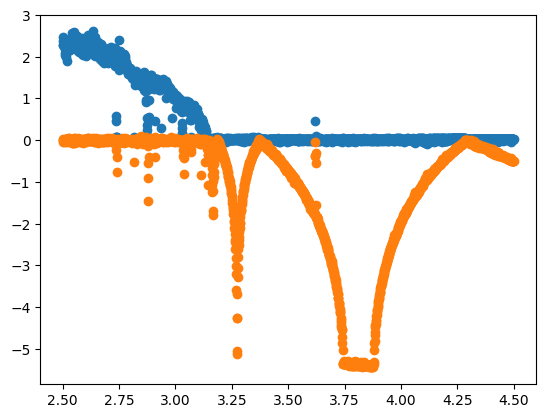

In [4]:
dados = np.fromfile('/storage/yuriassis/Chen-Ueta/lyap/exponents/[2.5, 4.5]_exp3.bin', dtype = np.float64)
dados = pd.DataFrame(dados.reshape(-1,6))
dados = dados.to_numpy()


plt.scatter(dados[:,1], dados[:,3])
plt.scatter(dados[:,1], dados[:,4])

--------------------------------------------------------------------

In [6]:
dados = np.fromfile('/storage/yuriassis/Chen-Ueta/teste/csv_basin/basin[3.5].bin', dtype = np.float64)
dados = pd.DataFrame(dados.reshape(-1,8))

print(dados)
meus_arrays1 = agrupar_em_dataframes(dados)


plt.figure(figsize=(15, 15), dpi = 1600)
for i in range(len(meus_arrays1)):
    meus_arrays1[i] = meus_arrays1[i].to_numpy()
    plt.scatter(meus_arrays1[i][:,0],meus_arrays1[i][:,1], marker = 's', s=0.75, label = 'periodo '+ str(int(meus_arrays1[i][0,2])),edgecolors='none')





plt.legend(markerscale = 10)
plt.xlim(-0.25,0.25)
plt.ylim(-0.25,0.25)
plt.xlabel('$x_0$',fontsize = 14)
plt.ylabel('$y_0$', fontsize = 14)
plt.tick_params(axis='both', which='major', labelsize=12)

             0         1    2          3    4    5    6    7
0      -0.2500 -0.250000  1.0  16.515492  0.0  0.0  0.0  0.0
1       0.0503 -0.250000  1.0  13.544323  0.0  0.0  0.0  0.0
2      -0.1499 -0.250000  1.0  16.515052  0.0  0.0  0.0  0.0
3       0.1504 -0.250000  1.0  13.544338  0.0  0.0  0.0  0.0
4      -0.0498 -0.250000  1.0  13.544148  0.0  0.0  0.0  0.0
...        ...       ...  ...        ...  ...  ...  ...  ...
999995  0.1499  0.247998  1.0  13.544317  0.0  0.0  0.0  0.0
999996  0.1499  0.248498  1.0  13.544061  0.0  0.0  0.0  0.0
999997  0.1499  0.248999  1.0  13.544339  0.0  0.0  0.0  0.0
999998  0.1499  0.249499  1.0  13.544308  0.0  0.0  0.0  0.0
999999  0.1499  0.250000  1.0  13.544108  0.0  0.0  0.0  0.0

[1000000 rows x 8 columns]


KeyboardInterrupt: 

-----------------------------------------------------------------------

# Começar a partir daqui
---------------------------------------------------------

#### Bifurcation with constant initial value


In [3]:
dir = "/storage/yuriassis/Chen-Ueta/bif_and_basins/csv_const_bif"
print(os.listdir(dir))

['bifurcacao[2.5, 4.5].bin', 'README.md', 'bifurcacao[0.0,10.0].bin']


In [8]:
caminho = "/storage/yuriassis/Chen-Ueta/bif_and_basins/csv_const_bif/bifurcacao[2.5, 4.5].bin"

dados = np.fromfile(caminho, dtype = np.float64)
dados = dados.reshape(-1,4)

plt.scatter(dados[:,1],dados[:,3],s = 0.1)

plt.title('Bifurcation - Fixed initial condition')
plt.xlabel('b')
plt.ylabel('x_max')

plt.savefig("figuras/bif_const_[2.5,4.5].png")
plt.close()

In [10]:
caminho = "/storage/yuriassis/Chen-Ueta/bif_and_basins/csv_const_bif/bifurcacao[0.0,10.0].bin"

dados = np.fromfile(caminho, dtype = np.float64)
dados = dados.reshape(-1,4)

plt.scatter(dados[:,1],dados[:,3],s = 0.1)

plt.title('Bifurcation - Fixed initial condition')
plt.xlabel('b')
plt.ylabel('x_max')

plt.savefig("figuras/bif_const_[0.0,10.0].png")
plt.close()


-----------------------------------------------------------------
#### Ida e Volta


In [24]:
caminho = "/storage/yuriassis/Chen-Ueta/bif_and_basins/csv_ida_volta"

plota_bif_IV(caminho, "Bifurcation - Biperiodicity veridication")


------------------------------------------------------------------
#### Multiperiodicity basins

Here is possible to add the xlim and ylim limits, using the arrays to define the better region for you.

In [44]:
caminho = "/storage/yuriassis/Chen-Ueta/bif_and_basins/csv_multiestabilidade"

plot_multi(caminho, "Multiperiodicity")

-----------------------------------------------------------------------------
#### Random initial conditions

In [88]:
caminho = "/storage/yuriassis/Chen-Ueta/bif_and_basins/csv_random"

plot_random(caminho, "Random Initial Conditions")

---------------------------------------------------------------------------------------------------
#### Different attraction basin

In [73]:
caminho = "/storage/yuriassis/Chen-Ueta/bif_and_basins/csv_attraction_basin"

plot_basins(caminho)

[             0         1    2          3    4    5    6    7
0      -0.2500 -0.250000  1.0  16.515492  0.0  0.0  0.0  0.0
1      -0.1499 -0.250000  1.0  16.515052  0.0  0.0  0.0  0.0
2      -0.2500 -0.249499  1.0  16.515463  0.0  0.0  0.0  0.0
3      -0.1499 -0.249499  1.0  16.515518  0.0  0.0  0.0  0.0
4      -0.2500 -0.248999  1.0  16.514987  0.0  0.0  0.0  0.0
...        ...       ...  ...        ...  ...  ...  ...  ...
348243  0.1499  0.190941  1.0  16.515525  0.0  0.0  0.0  0.0
348244  0.1499  0.191441  1.0  16.515007  0.0  0.0  0.0  0.0
348245  0.1499  0.191942  1.0  16.515194  0.0  0.0  0.0  0.0
348246  0.1499  0.192442  1.0  16.515474  0.0  0.0  0.0  0.0
348247  0.1499  0.192943  1.0  16.515239  0.0  0.0  0.0  0.0

[348248 rows x 8 columns],              0         1    2          3    4    5    6    7
0       0.0503 -0.250000  1.0  13.544323  0.0  0.0  0.0  0.0
1       0.1504 -0.250000  1.0  13.544338  0.0  0.0  0.0  0.0
2      -0.0498 -0.250000  1.0  13.544148  0.0  0.0  0.0 

/tmp/ipykernel_2889899/3480377319.py:99: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig("figuras/" + name_fig)


[            0         1    2          3          4          5          6  \
0     -0.1499 -0.250000  5.0  11.362956  12.426855  15.604671  19.796998   
1     -0.0498 -0.250000  5.0  11.363000  12.427147  15.605000  19.798851   
2     -0.1499 -0.249499  5.0  11.371295  12.436420  15.610403  19.812753   
3     -0.0498 -0.249499  5.0  11.362933  12.426784  15.604553  19.797051   
4     -0.1499 -0.248999  5.0  11.371435  12.436274  15.609691  19.813276   
...       ...       ...  ...        ...        ...        ...        ...   
85887  0.1499  0.247998  5.0  11.442060  12.471753  15.563231  19.866752   
85888  0.1499  0.248498  5.0  11.442013  12.471808  15.563605  19.866593   
85889  0.1499  0.248999  5.0  11.441985  12.471298  15.563521  19.868604   
85890  0.1499  0.249499  5.0  11.442034  12.471797  15.563473  19.866140   
85891  0.1499  0.250000  5.0  11.464568  12.467770  15.550855  19.860957   

               7  
0      26.774467  
1      26.775205  
2      26.782606  
3      26.

/tmp/ipykernel_2889899/3480377319.py:99: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig("figuras/" + name_fig)


[             0         1    2          3          4    5    6    7
0      -0.2500 -0.250000  2.0  15.348366  16.479887  0.0  0.0  0.0
1      -0.0498 -0.250000  2.0  15.350108  16.481165  0.0  0.0  0.0
2       0.0503 -0.250000  2.0  15.349698  16.480401  0.0  0.0  0.0
3      -0.2500 -0.249499  2.0  15.350239  16.481212  0.0  0.0  0.0
4      -0.0498 -0.249499  2.0  15.351376  16.480665  0.0  0.0  0.0
...        ...       ...  ...        ...        ...  ...  ...  ...
469289  0.2500  0.242993  2.0  15.351077  16.481119  0.0  0.0  0.0
469290  0.2500  0.244494  2.0  15.350441  16.481024  0.0  0.0  0.0
469291  0.2500  0.245495  2.0  15.349777  16.480376  0.0  0.0  0.0
469292  0.2500  0.246496  2.0  15.349809  16.481501  0.0  0.0  0.0
469293  0.2500  0.246997  2.0  15.352935  16.479815  0.0  0.0  0.0

[469294 rows x 8 columns],             0         1    2         3          4          5          6  \
0     -0.1499 -0.250000  5.0 -2.883846  10.800424  11.184040  15.876478   
1     -0.1499 -0.

/tmp/ipykernel_2889899/3480377319.py:99: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig("figuras/" + name_fig)


---------------------------------------------------------------------------
#### Zooming the basin of 3.195

In [87]:
caminho = "/storage/yuriassis/Chen-Ueta/bif_and_basins/csv_zoom_basin"

plot_zoom_basins(caminho)

/tmp/ipykernel_2889899/1440396370.py:124: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig("figuras/" + name_fig)


In [ ]:
dados = np.fromfile('/storage/yuriassis/Chen-Ueta/bif_and_basins/csv_attraction_basin', dtype = np.float64)
dados = pd.DataFrame(dados.reshape(-1,8))